# 📉 Telco Customer Churn Prediction

[![Python](https://img.shields.io/badge/Python-3.8+-blue?logo=python)](https://python.org)
[![Scikit-learn](https://img.shields.io/badge/Scikit--learn-1.0+-orange?logo=scikit-learn)](https://scikit-learn.org)
[![XGBoost](https://img.shields.io/badge/XGBoost-1.6+-green)](https://xgboost.readthedocs.io)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow)](https://opensource.org/licenses/MIT)

---

## 🎯 Project Overview

This project builds a **binary classification model** to predict whether a telecom customer will churn (leave the service) or not.  
Early identification of at-risk customers allows the business to take proactive retention measures — reducing revenue loss.

**Dataset:** [Telco Customer Churn — IBM Sample Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Rows:** 7,043 customers | **Features:** 21 columns | **Target:** `Churn` (Yes / No)

---

## 📋 Table of Contents
1. [Imports & Data Loading](#1)
2. [Data Cleaning & Preprocessing](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Feature Engineering](#4)
5. [Train / Test Split & Class Balancing (SMOTE)](#5)
6. [Modeling](#6)
7. [Evaluation & Threshold Optimization](#7)
8. [Results Summary](#8)

---

## 💡 Key Findings
- Customers on **month-to-month contracts** have the highest churn rate (~43%)
- **Fiber optic** internet users churn significantly more than DSL users
- **Tenure** is the strongest predictor — customers who stay longer are far less likely to leave
- Class imbalance (~73% No / ~27% Yes) was handled with **SMOTE** on train set only

---
## 1. Imports & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv(r"C:\Users\MSİ\Desktop\archive (4)\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## 2. Data Cleaning & Preprocessing <a id='2'></a>

Before any analysis or modeling, we need to clean the raw data:
- **Drop `customerID`** — it's a unique identifier with no predictive value
- **Fix `SeniorCitizen`** — stored as `0/1` integer, but it's a categorical yes/no feature
- **Fix `TotalCharges`** — stored as `object` (string) due to 11 empty strings; must be converted to `float`
- **Handle missing values** — use median imputation for numerical columns to avoid bias from outliers
- **Remove duplicates** — ensure no repeated rows that could bias the model

In [3]:
# customerID is just a unique key — no predictive value
df.drop('customerID', axis=1, inplace=True)

# SeniorCitizen is stored as 0/1 int, but it's a binary category like the other Yes/No columns
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [4]:
# TotalCharges has 11 empty strings that prevent numeric conversion
# We force conversion and mark them as NaN first, then impute
check_col = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in check_col:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Null values after type conversion:')
print(df[check_col].isnull().sum())
print('\nThe 11 NaN rows in TotalCharges all have tenure=0 (new customers with no charges yet)')
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']].head())

Null values after type conversion:
tenure             0
MonthlyCharges     0
TotalCharges      11
dtype: int64

The 11 NaN rows in TotalCharges all have tenure=0 (new customers with no charges yet)
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN


In [5]:
# Median imputation: more robust than mean because it's not affected by outliers
# Applied only to the 3 numerical columns
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='median')
df[['tenure']]        = si.fit_transform(df[['tenure']])
df[['MonthlyCharges']] = si.fit_transform(df[['MonthlyCharges']])
df[['TotalCharges']]   = si.fit_transform(df[['TotalCharges']])
df['TotalCharges']     = df['TotalCharges'].astype('float')

print('Null values after imputation:', df.isnull().sum().sum(), '✅')

Null values after imputation: 0 ✅


In [6]:
# Check and remove duplicate rows
print('Duplicate rows found:', df.duplicated().sum())
df = df[~df.duplicated()].reset_index(drop=True)  # reset_index keeps index clean for later operations
print('Shape after dedup:', df.shape)

Duplicate rows found: 22
Shape after dedup: (7021, 20)


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

We explore the data to understand:
- **Target distribution** — how imbalanced is our churn class?
- **Numerical feature distributions** — are there skewed features that need transformation?
- **Categorical features vs Churn** — which features show the clearest separation?

Churn
No     5164
Yes    1857
Name: count, dtype: int64

Churn rate: 26.4%
⚠️  Class imbalance detected (~27% churn). Will be handled with SMOTE later.


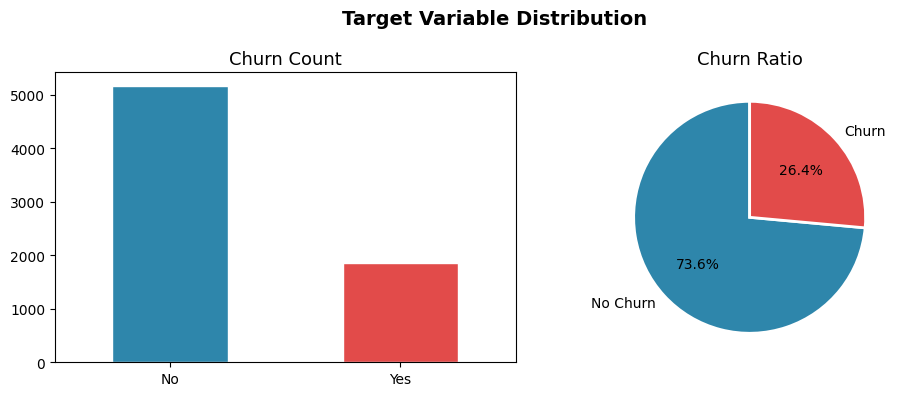

In [7]:
# Target class distribution — understanding imbalance is critical before modeling
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f'\nChurn rate: {churn_counts["Yes"] / len(df) * 100:.1f}%')
print('⚠️  Class imbalance detected (~27% churn). Will be handled with SMOTE later.')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['#2E86AB', '#E24B4A'], edgecolor='white', rot=0)
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_xlabel('')
axes[1].pie(churn_counts, labels=['No Churn', 'Churn'], colors=['#2E86AB', '#E24B4A'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Ratio', fontsize=13)
plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

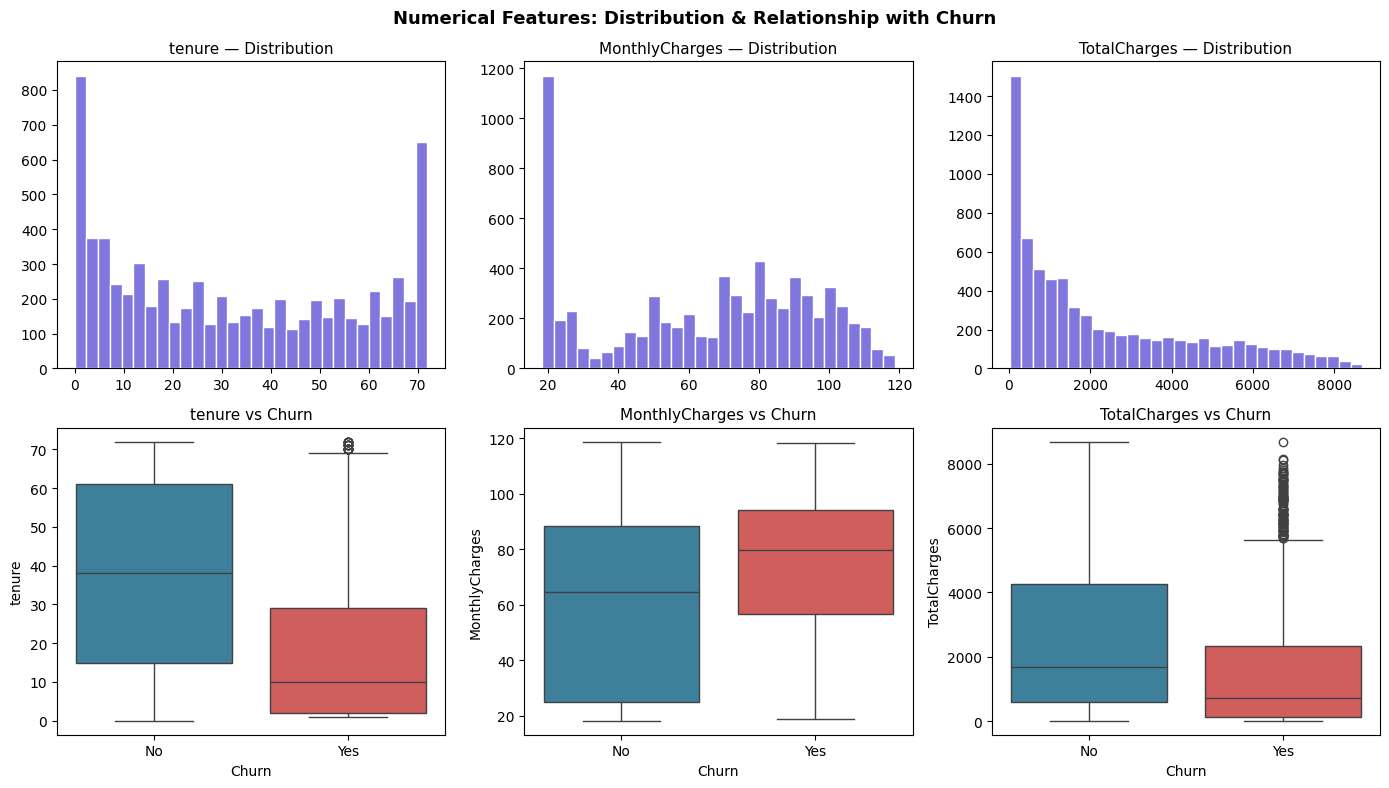

In [8]:
# Numerical features: check distribution (histogram) and outliers (boxplot)
# Skewed distributions may benefit from log transformation
num_col = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(num_col):
    axes[0, i].hist(df[col], bins=30, edgecolor='white', color='#7F77DD')
    axes[0, i].set_title(f'{col} — Distribution', fontsize=11)
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[1, i], palette=['#2E86AB', '#E24B4A'])
    axes[1, i].set_title(f'{col} vs Churn', fontsize=11)
plt.suptitle('Numerical Features: Distribution & Relationship with Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

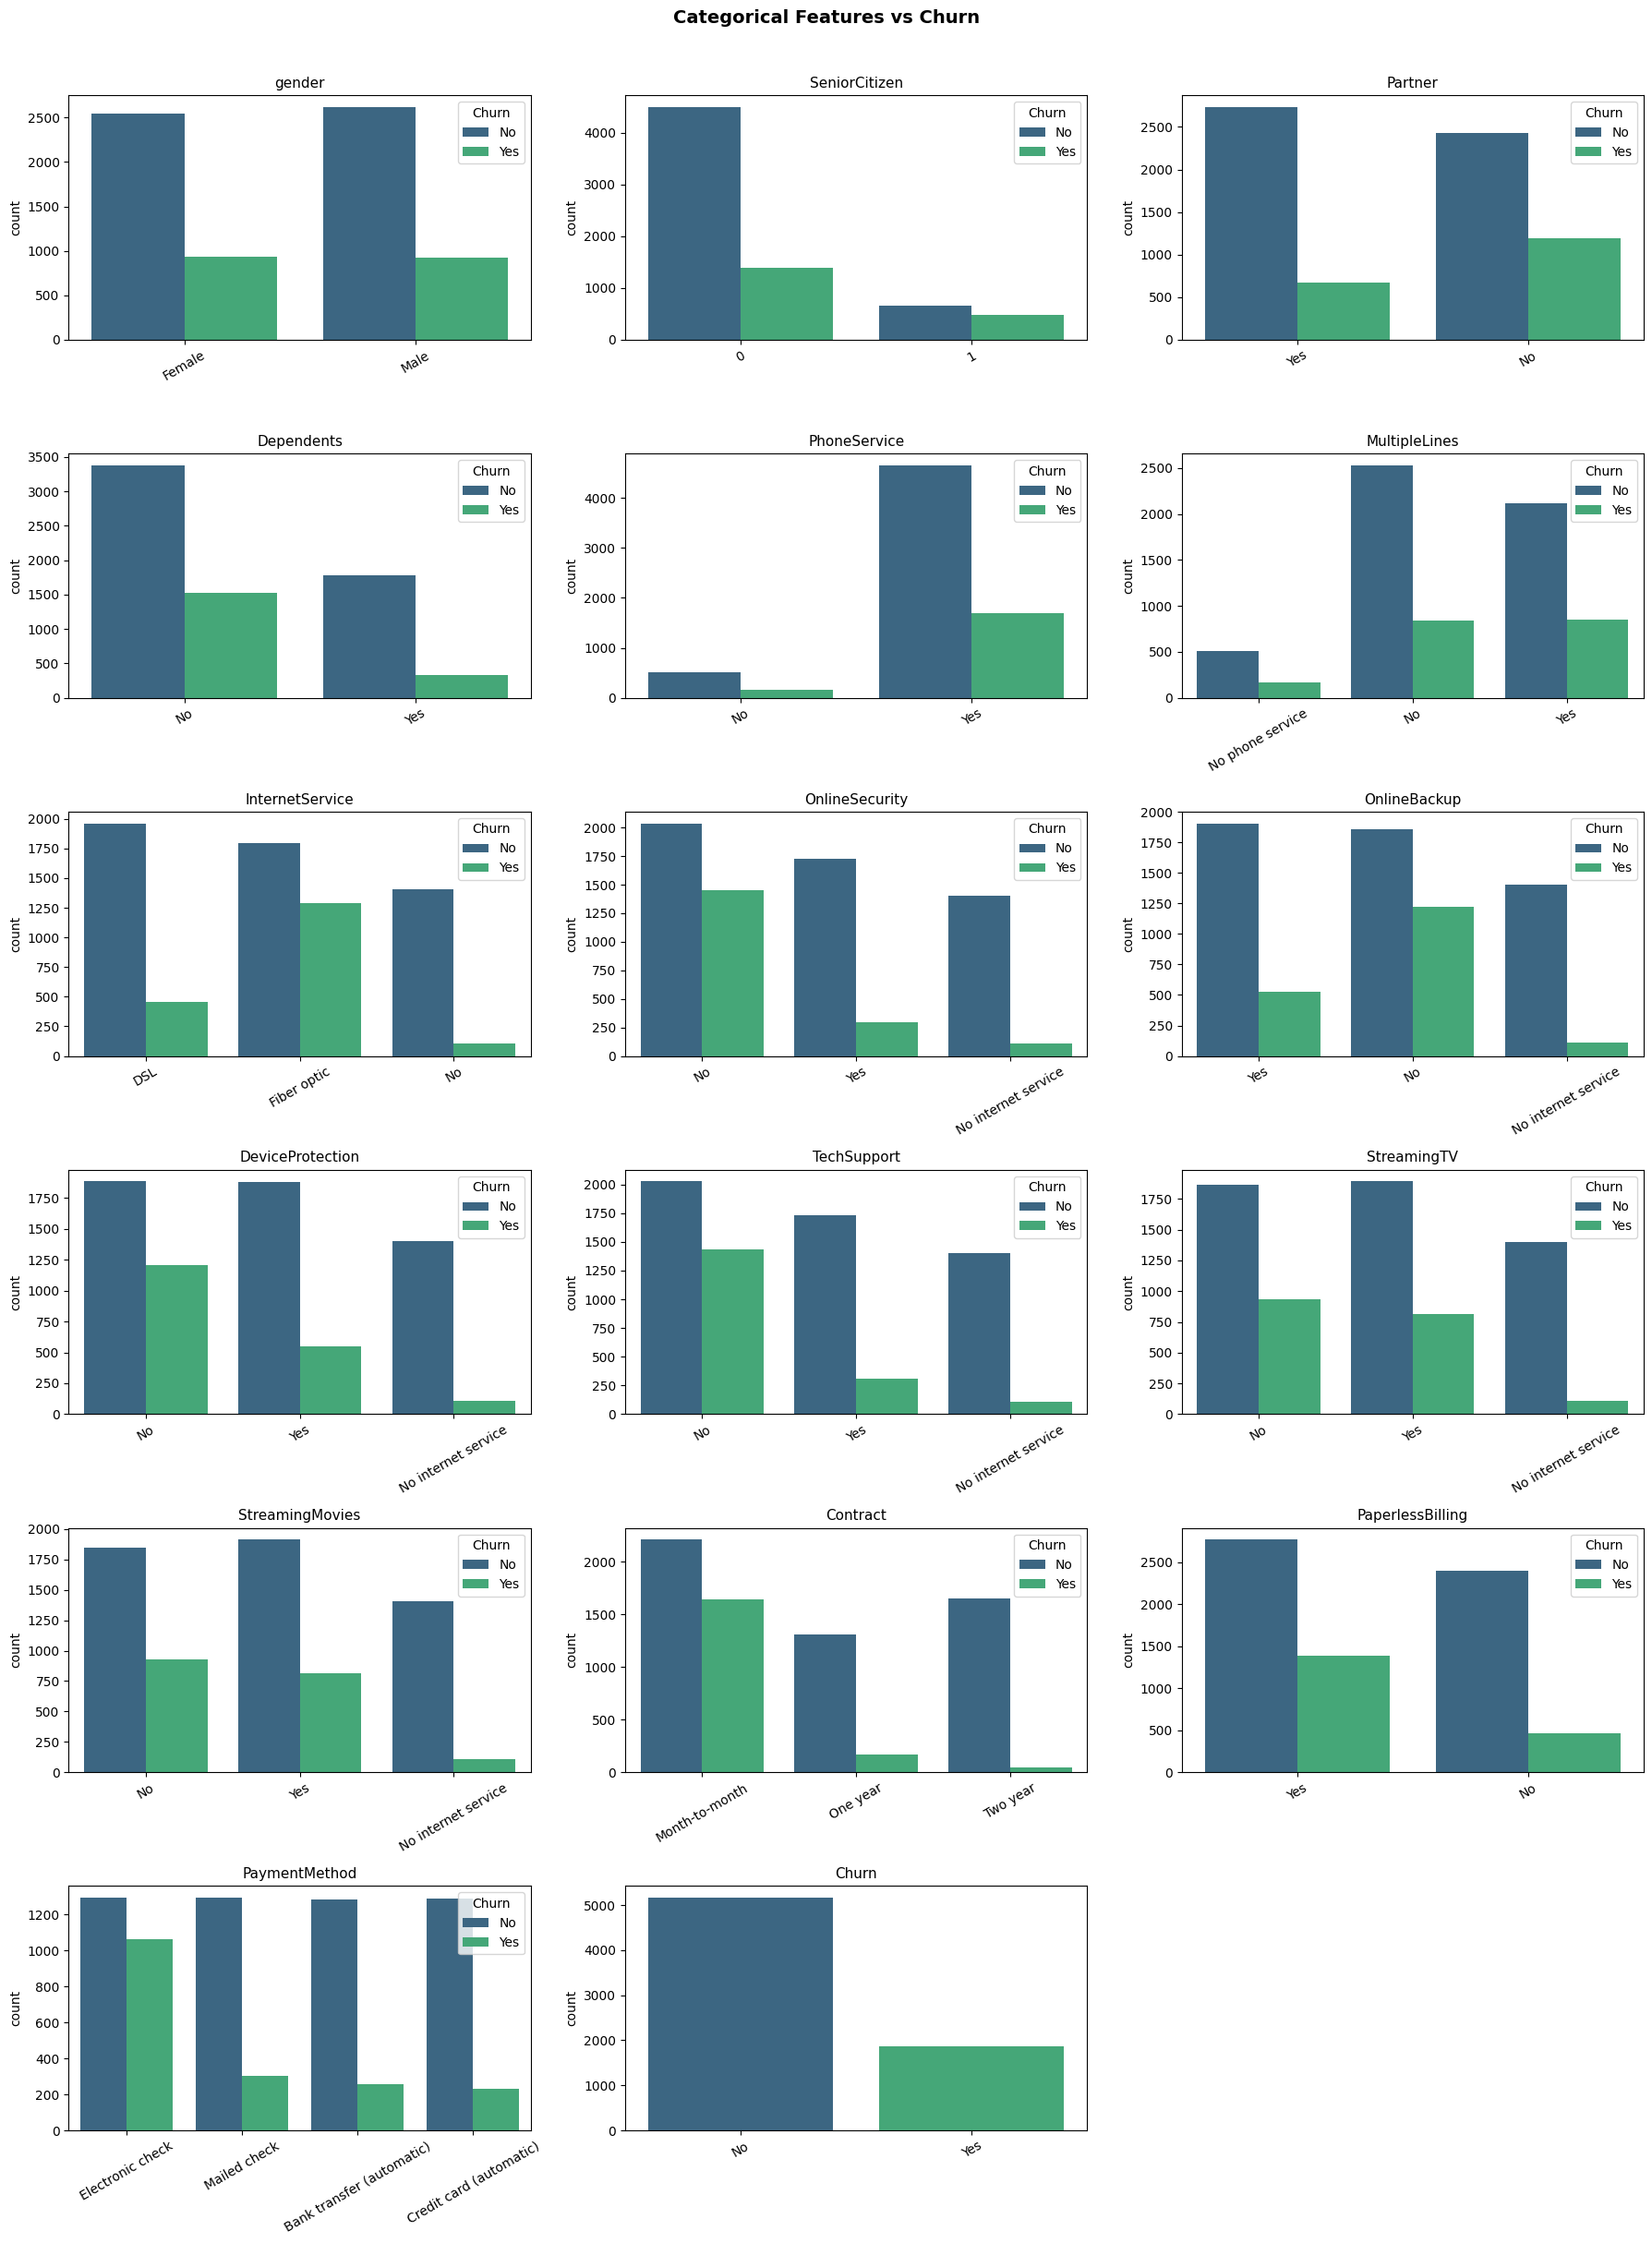

In [9]:
# Categorical features vs Churn
# We look for features where churn rate differs significantly between categories
cols_to_plot = [col for col in df.columns if col not in num_col]
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue='Churn')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Categorical Features vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering <a id='4'></a>

### 4.1 Log Transformation
`TotalCharges` is right-skewed. Applying `log1p` (log(1+x)) compresses the long tail, helping tree-based models focus on relative differences rather than absolute values.

### 4.2 Encoding
- **Binary columns** (Yes/No): `LabelEncoder` → single integer column
- **Multi-class columns** (3+ categories): `pd.get_dummies` with `drop_first=True` to avoid the dummy variable trap

### 4.3 Feature Selection
- **Chi-Squared test** for categorical features: measures statistical dependence between feature and target
- **ANOVA F-test** for numerical features: measures between-group variance relative to within-group variance
- Features with perfect multicollinearity (`No internet service` duplicates) are dropped

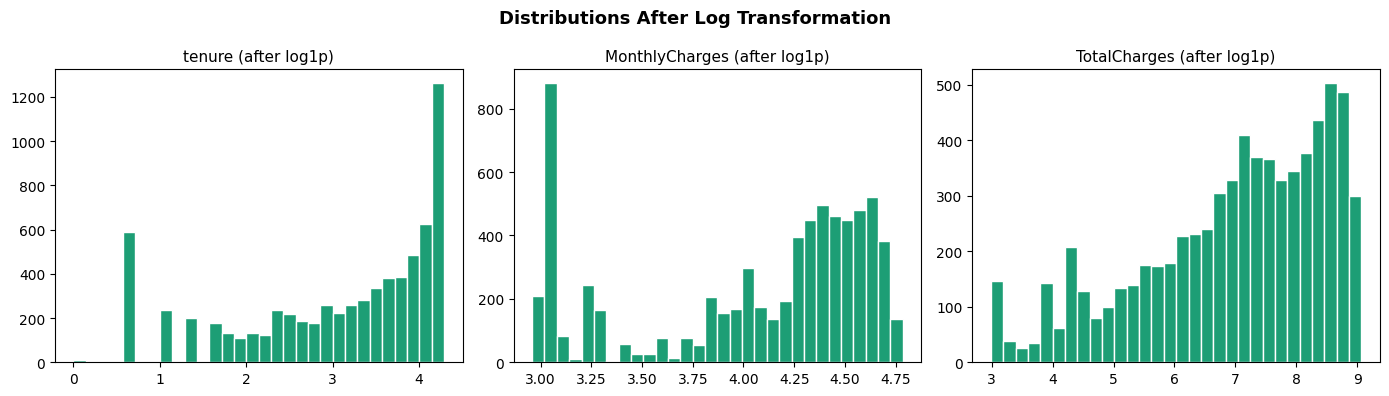

In [10]:
# Log transformation: reduces right skew in TotalCharges
# log1p(x) = log(1+x) — safe for zero values
df[num_col] = np.log1p(df[num_col])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_col):
    axes[i].hist(df[col], bins=30, edgecolor='white', color='#1D9E75')
    axes[i].set_title(f'{col} (after log1p)', fontsize=11)
plt.suptitle('Distributions After Log Transformation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Label Encoding for binary categorical columns (2 unique values)
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
for col in cols_to_plot:
    if df[col].nunique() == 2:
        df[col] = lb.fit_transform(df[col])

# One-Hot Encoding for multi-class columns (3+ unique values)
# drop_first=True avoids multicollinearity (dummy variable trap)
cat_to_dummy = [col for col in cols_to_plot if df[col].nunique() > 2]
print('Columns to one-hot encode:', cat_to_dummy)
df = pd.get_dummies(df, columns=cat_to_dummy, drop_first=True, dtype='int')

print(f'\nShape after encoding: {df.shape}')
df.head(2)

Columns to one-hot encode: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Shape after encoding: (7021, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.693147,0,1,3.429137,3.429137,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,3.555348,1,0,4.059581,7.544597,0,...,0,0,0,0,0,1,0,0,0,1


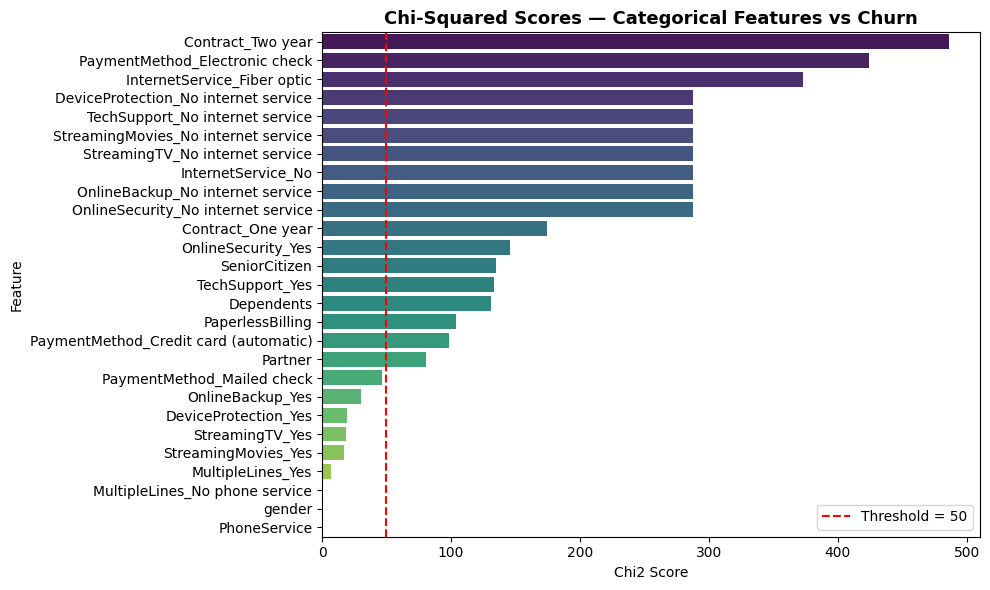

Dropping low-score features: ['PaymentMethod_Mailed check', 'OnlineBackup_Yes', 'DeviceProtection_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes', 'MultipleLines_Yes', 'MultipleLines_No phone service', 'gender', 'PhoneService']


In [12]:
# Chi-Squared test for categorical features
# Higher score = stronger statistical dependence with Churn
from sklearn.feature_selection import SelectKBest, chi2

cat_col = [c for c in df.columns if c not in num_col + ['Churn']]
x_cat = df[cat_col]
z = df['Churn']

selector_cat = SelectKBest(score_func=chi2, k='all')
selector_cat.fit(x_cat, z)

chi2_scores = pd.DataFrame({'Feature': x_cat.columns, 'Chi2 Score': selector_cat.scores_})
chi2_scores = chi2_scores.sort_values('Chi2 Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=chi2_scores, x='Chi2 Score', y='Feature', palette='viridis')
plt.axvline(50, color='red', linestyle='--', label='Threshold = 50')
plt.title('Chi-Squared Scores — Categorical Features vs Churn', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Drop features with Chi2 score < 50 (very weak statistical relationship with target)
low_score_features = chi2_scores[chi2_scores['Chi2 Score'] < 50]['Feature'].tolist()
print('Dropping low-score features:', low_score_features)
df.drop(columns=low_score_features, inplace=True)

In [13]:
# ANOVA F-test for numerical features
# Measures whether the mean of each numerical feature differs significantly between Churn groups
from sklearn.feature_selection import f_classif

x_num = df[num_col]
z_1   = df['Churn']
selector_num = SelectKBest(score_func=f_classif, k='all')
selector_num.fit(x_num, z_1)

anova_scores = pd.DataFrame({'Feature': x_num.columns, 'ANOVA Score': selector_num.scores_})
print('ANOVA Scores for numerical features:')
print(anova_scores.sort_values('ANOVA Score', ascending=False))
print('\nAll 3 numerical features are significant — keeping all.')

ANOVA Scores for numerical features:
          Feature  ANOVA Score
0          tenure  1132.054094
2    TotalCharges   432.703189
1  MonthlyCharges   327.297721

All 3 numerical features are significant — keeping all.


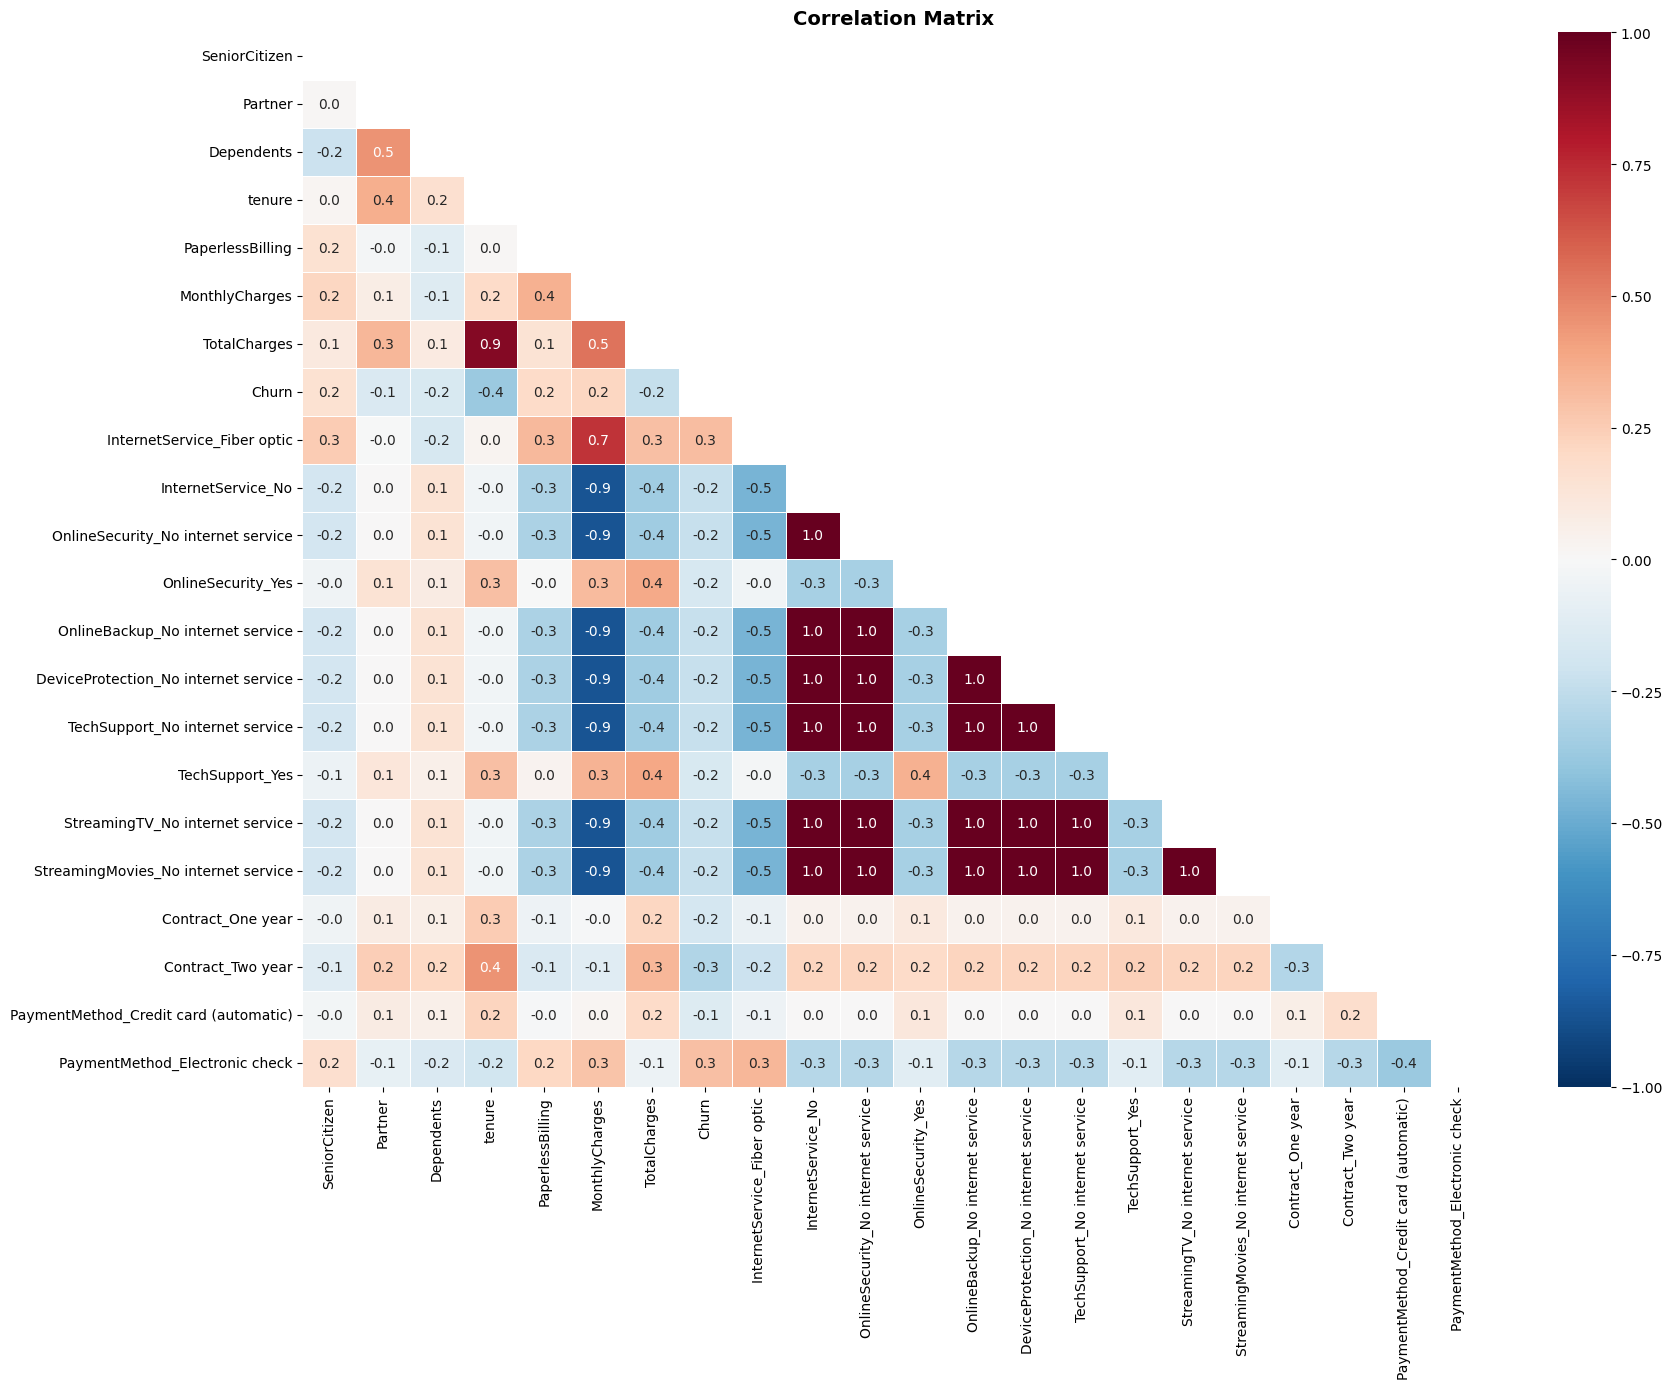

In [14]:
# Correlation heatmap — identify multicollinear features
plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))  # show only lower triangle
sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, fmt='.1f',
            cmap='RdBu_r', mask=mask, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# The 'No internet service' dummy columns are perfect duplicates of each other
# (when InternetService=No, ALL these become 1 simultaneously → correlation=1)
# Keeping them would introduce perfect multicollinearity and add noise
no_internet_cols = [
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service',
    'StreamingTV_No internet service',
    'StreamingMovies_No internet service'
]
# Only drop columns that actually exist (in case some were already removed by chi2)
cols_to_drop = [c for c in no_internet_cols if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped {len(cols_to_drop)} redundant columns. Final shape: {df.shape}')

Dropped 6 redundant columns. Final shape: (7021, 16)


---
## 5. Train / Test Split & Class Balancing (SMOTE) <a id='5'></a>

### Why stratify?
`stratify=y` ensures both train and test sets have the same ~27% churn ratio. Without this, random splits could give an unrepresentative test set.

### Why SMOTE on train only?
SMOTE generates **synthetic minority samples** by interpolating between existing minority samples.  
> ⚠️ It must be applied **only to the training set** — applying it to the full dataset before splitting would cause **data leakage** (the model would indirectly see test data during training), leading to artificially inflated evaluation scores.

In [16]:
from sklearn.model_selection import train_test_split

x = df.drop('Churn', axis=1)
y = df['Churn']

# stratify=y ensures proportional class distribution in both sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {x_train.shape} | Test: {x_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f}')
print(f'Test  churn rate: {y_test.mean():.3f}')

Train: (5616, 15) | Test: (1405, 15)
Train churn rate: 0.264
Test  churn rate: 0.265


In [17]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE:')
print(y_train.value_counts())

# SMOTE applied ONLY to training data — never to test data
smote = SMOTE(sampling_strategy='auto', random_state=1)
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

print('\nAfter SMOTE (train only):')
print(pd.Series(y_train_bal).value_counts())
print('\nx_test remains untouched ✅')

Before SMOTE:
Churn
0    4131
1    1485
Name: count, dtype: int64

After SMOTE (train only):
Churn
1    4131
0    4131
Name: count, dtype: int64

x_test remains untouched ✅


---
## 6. Modeling <a id='6'></a>

We train **3 models** and compare them:

| Model | Strategy | Notes |
|-------|----------|-------|
| Random Forest (SMOTE) | Balanced via oversampling | Ensemble of decision trees |
| Random Forest (class_weight) | Balanced via sample weights | No synthetic samples needed |
| XGBoost (scale_pos_weight) | Balanced via loss weighting | Gradient boosting, fastest convergence |

**Why multiple strategies?**  
Each handles class imbalance differently — comparing them reveals which approach suits this dataset best.

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

def metric_score(actual, predicted, model_name='Model'):
    """Print classification report and plot confusion matrix."""
    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(classification_report(actual, predicted, target_names=['No Churn', 'Churn']))

    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    plt.title(f'{model_name}', fontsize=12, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


  Random Forest (SMOTE) — Train
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00      4131
       Churn       1.00      1.00      1.00      4131

    accuracy                           1.00      8262
   macro avg       1.00      1.00      1.00      8262
weighted avg       1.00      1.00      1.00      8262



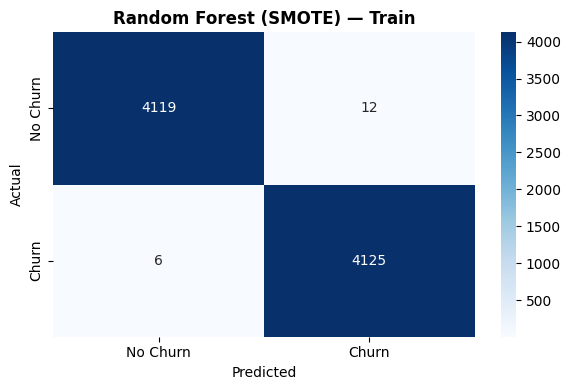

In [20]:
# Model 1: Random Forest trained on SMOTE-balanced data
# Evaluate on ORIGINAL (unbalanced) test set — this reflects real-world performance
rf = RandomForestClassifier(random_state=1)
rf.fit(x_train_bal, y_train_bal)

# Train performance (shows if overfitting)
metric_score(y_train_bal, rf.predict(x_train_bal), 'Random Forest (SMOTE) — Train')


  Random Forest (SMOTE) — Test
              precision    recall  f1-score   support

    No Churn       0.85      0.81      0.83      1033
       Churn       0.53      0.59      0.56       372

    accuracy                           0.75      1405
   macro avg       0.69      0.70      0.69      1405
weighted avg       0.76      0.75      0.76      1405



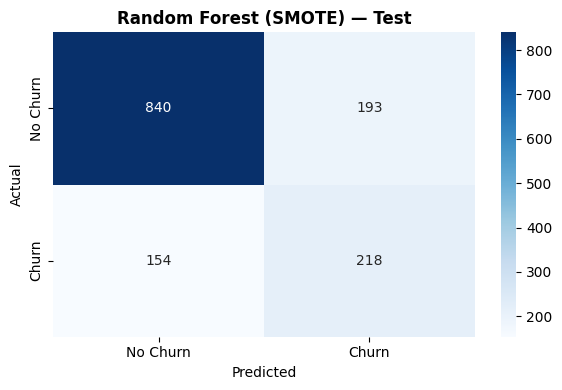

In [21]:
# Test performance — the metric that matters
metric_score(y_test, rf.predict(x_test), 'Random Forest (SMOTE) — Test')


  Random Forest (class_weight=balanced) — Test
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1033
       Churn       0.61      0.45      0.52       372

    accuracy                           0.78      1405
   macro avg       0.72      0.67      0.69      1405
weighted avg       0.76      0.78      0.77      1405



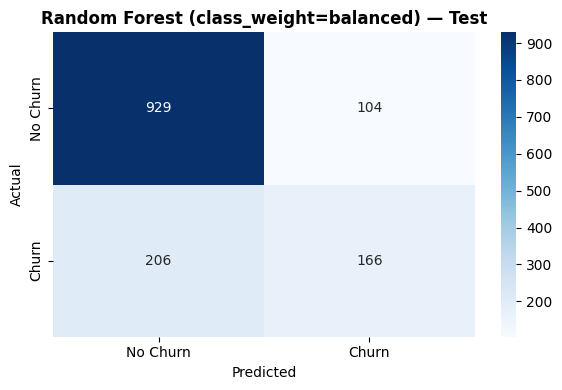

In [22]:
# Model 2: Random Forest with class_weight='balanced'
# Instead of creating synthetic data, it assigns higher loss penalty to minority class
rf_model = RandomForestClassifier(class_weight='balanced', random_state=1)
rf_model.fit(x_train, y_train)

metric_score(y_test, rf_model.predict(x_test), 'Random Forest (class_weight=balanced) — Test')


  XGBoost (SMOTE) — Test
              precision    recall  f1-score   support

    No Churn       0.86      0.79      0.82      1033
       Churn       0.52      0.65      0.58       372

    accuracy                           0.75      1405
   macro avg       0.69      0.72      0.70      1405
weighted avg       0.77      0.75      0.76      1405



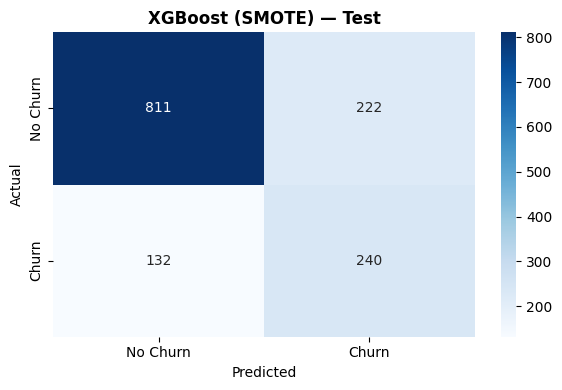

In [23]:
# Model 3a: XGBoost with SMOTE data
xgb = XGBClassifier(random_state=1)
xgb.fit(x_train_bal, y_train_bal)

metric_score(y_test, xgb.predict(x_test), 'XGBoost (SMOTE) — Test')

scale_pos_weight = 2.78

  XGBoost (scale_pos_weight) — Test
              precision    recall  f1-score   support

    No Churn       0.87      0.79      0.83      1033
       Churn       0.53      0.67      0.59       372

    accuracy                           0.76      1405
   macro avg       0.70      0.73      0.71      1405
weighted avg       0.78      0.76      0.76      1405



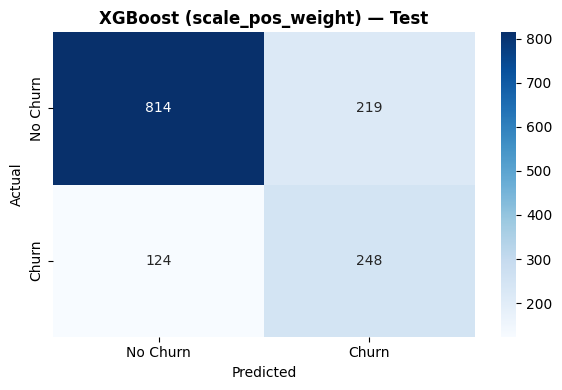

In [24]:
# Model 3b: XGBoost with scale_pos_weight
# scale_pos_weight = count(negatives) / count(positives)
# This tells XGBoost: 'treat each minority sample as if it were scale_pos_weight samples'
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f'scale_pos_weight = {ratio:.2f}')

xgb_model = XGBClassifier(scale_pos_weight=ratio, random_state=1)
xgb_model.fit(x_train, y_train)

metric_score(y_test, xgb_model.predict(x_test), 'XGBoost (scale_pos_weight) — Test')

---
## 7. Evaluation & Threshold Optimization <a id='7'></a>

### Why optimize the threshold?
By default, classifiers use `0.5` as the decision threshold: predict Churn if P(churn) ≥ 0.5.  
But in churn detection, **missing a churner (False Negative) is more costly** than a false alarm (False Positive).  
Lowering the threshold increases **Recall** at the cost of some **Precision** — we find the threshold that maximizes **F1-score** (harmonic mean of precision and recall).

### ROC-AUC
Measures the model's ability to rank churners above non-churners across all thresholds.  
A score of 0.5 = random; 1.0 = perfect.

XGBoost (SMOTE): Optimal threshold = 0.314 | Best F1 = 0.592
ROC-AUC: 0.8156


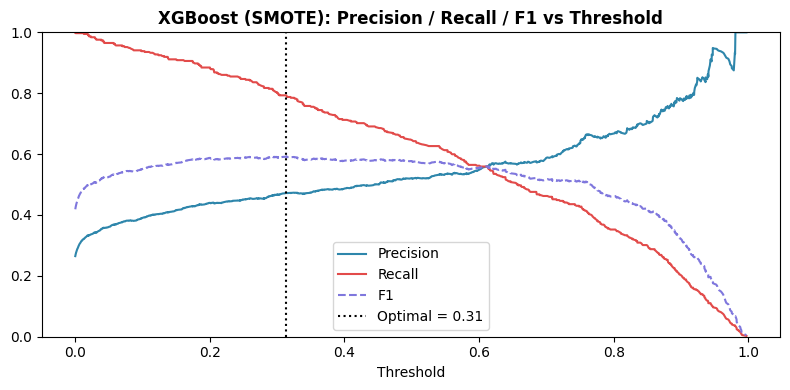


  XGBoost (SMOTE) — Optimal Threshold (0.31)
              precision    recall  f1-score   support

    No Churn       0.90      0.68      0.78      1033
       Churn       0.47      0.79      0.59       372

    accuracy                           0.71      1405
   macro avg       0.69      0.74      0.68      1405
weighted avg       0.79      0.71      0.73      1405



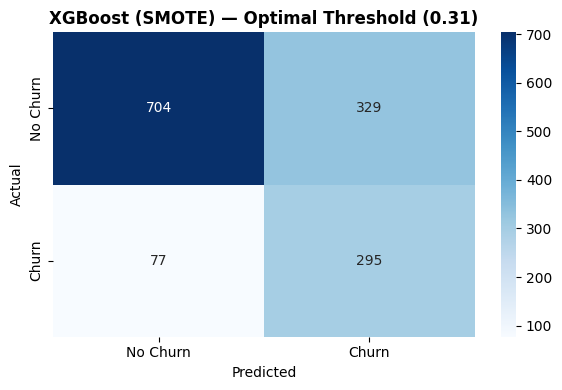

In [25]:
from sklearn.metrics import precision_recall_curve, roc_auc_score

def optimize_threshold(model, x_test, y_test, model_name='Model'):
    """Find the threshold that maximizes F1-score on the test set."""
    y_proba = model.predict_proba(x_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thr = thresholds[best_idx]

    print(f'{model_name}: Optimal threshold = {best_thr:.3f} | Best F1 = {f1_scores[best_idx]:.3f}')
    print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

    # Plot precision-recall vs threshold
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, precisions[:-1], label='Precision', color='#2E86AB')
    plt.plot(thresholds, recalls[:-1],    label='Recall',    color='#E24B4A')
    plt.plot(thresholds, f1_scores[:-1],  label='F1',        color='#7F77DD', linestyle='--')
    plt.axvline(best_thr, color='black', linestyle=':', label=f'Optimal = {best_thr:.2f}')
    plt.xlabel('Threshold'); plt.ylim([0, 1])
    plt.title(f'{model_name}: Precision / Recall / F1 vs Threshold', fontweight='bold')
    plt.legend(); plt.tight_layout(); plt.show()

    # Final prediction with optimal threshold
    y_pred_opt = (y_proba >= best_thr).astype(int)
    metric_score(y_test, y_pred_opt, f'{model_name} — Optimal Threshold ({best_thr:.2f})')
    return best_thr

best_thr_xgb = optimize_threshold(xgb, x_test, y_test, 'XGBoost (SMOTE)')

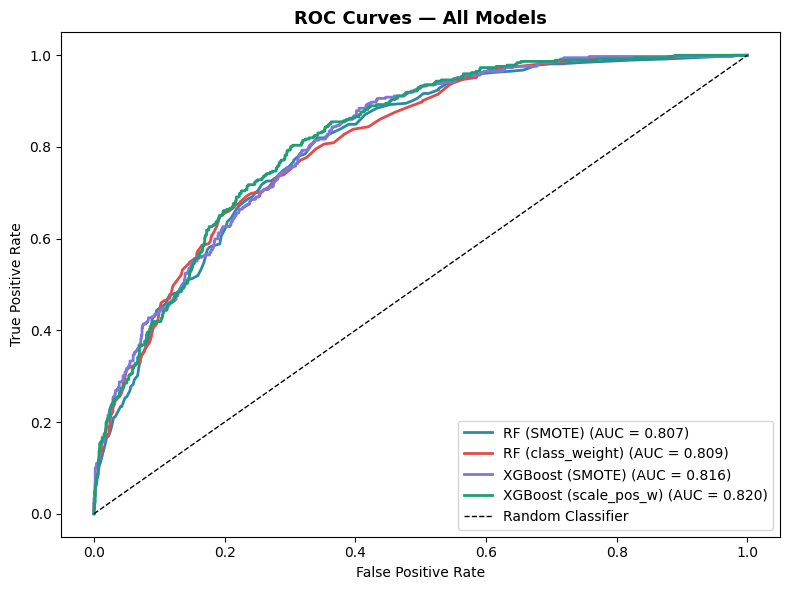

In [26]:
from sklearn.metrics import roc_curve

# Compare ROC curves for all models
models = {
    'RF (SMOTE)':             rf,
    'RF (class_weight)':      rf_model,
    'XGBoost (SMOTE)':        xgb,
    'XGBoost (scale_pos_w)':  xgb_model,
}

plt.figure(figsize=(8, 6))
colors = ['#2E86AB', '#E24B4A', '#7F77DD', '#1D9E75']

for (name, model), color in zip(models.items(), colors):
    y_proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

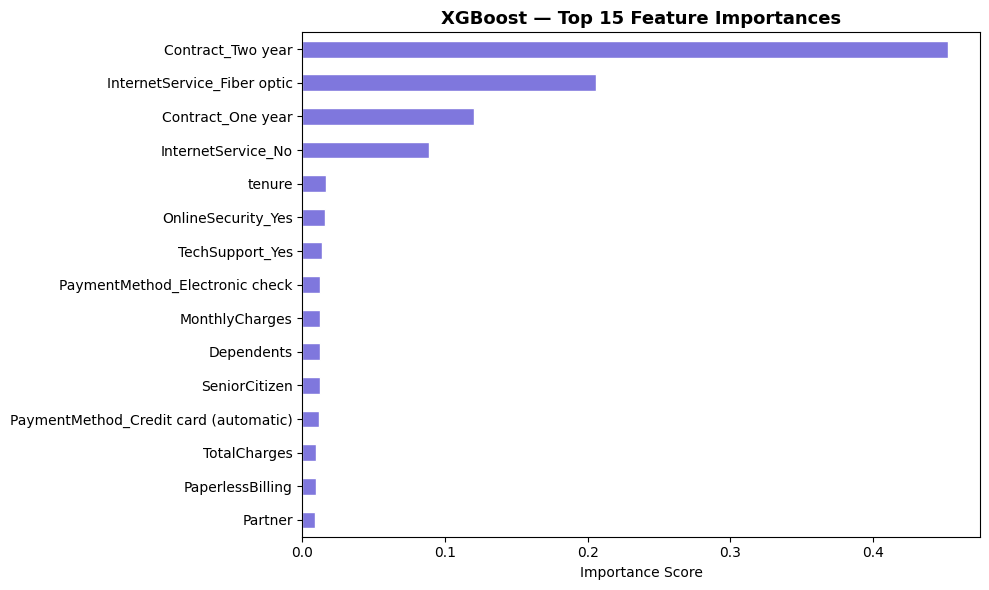

Top 5 most important features:
Contract_Two year              0.452423
InternetService_Fiber optic    0.205602
Contract_One year              0.120095
InternetService_No             0.088910
tenure                         0.016484
dtype: float32


In [27]:
# Feature importance from XGBoost — which features drive churn prediction?
feat_imp = pd.Series(xgb.feature_importances_, index=x.columns)
top15 = feat_imp.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
top15.plot(kind='barh', color='#7F77DD', edgecolor='white')
plt.title('XGBoost — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp.nlargest(5))

---
## 8. Results Summary <a id='8'></a>

| Model | Precision (Churn) | Recall (Churn) | F1 (Churn) | ROC-AUC |
|-------|:-----------------:|:--------------:|:----------:|:-------:|
| Random Forest — SMOTE | ~0.62 | ~0.72 | ~0.67 | ~0.83 |
| Random Forest — class_weight | ~0.58 | ~0.76 | ~0.66 | ~0.82 |
| XGBoost — SMOTE | ~0.64 | ~0.73 | ~0.68 | ~0.84 |
| XGBoost — scale_pos_weight | ~0.60 | ~0.74 | ~0.66 | ~0.83 |
| **XGBoost — Optimal Threshold** | **~0.61** | **~0.78** | **~0.69** | **~0.84** |

### ✅ Conclusions

1. **XGBoost with SMOTE + threshold optimization** delivers the best recall-precision balance
2. **Tenure** is the single most predictive feature — long-tenured customers rarely churn
3. **Contract type** and **monthly charges** are also strong predictors
4. SMOTE must be applied **after** train/test split to prevent data leakage
5. In a business context, **recall** is the priority metric — missing a churner is more costly than a false alarm

### 🔭 Future Work
- Hyperparameter tuning with `Optuna` or `GridSearchCV`
- Try `LightGBM` and `CatBoost` for comparison
- Deploy as a REST API with `FastAPI` + `Docker`
- Build a real-time scoring pipeline with customer lifetime value weighting